#Question 1: Two-Dimensional Random Walk


---


A particle starts at the origin (0, 0) and takes 100 random steps on a 2D grid. At each
step, it moves:

• Right (+1, 0) with probability 1/4

• Left (−1, 0) with probability 1/4

• Up (0, +1) with probability 1/4

• Down (0, −1) with probability 1/4

Run 500 independent random walks and analyze the spreading behavior.


---


Part (a): Simulate 500 random walks, each with 100 steps. For each walk, record the
final position (x, y) and calculate the distance from origin r =
sqrt(x2 + y2)
. Store these distances in an array called final distances.


---


Part (b): Create a histogram with 25 bins showing the distribution of final distances from
all 500 walks.

Label the x-axis as “Distance from Origin” and the y-axis as “Frequency”.
Add a title “Random Walk: Distribution of Final Distances”.


---


Part (c): Calculate the average of r^2
(the squared distances) and store it in a vari-able called avg r squared. Print the result with the message “Average r-squared = X
(theoretical value = 100)”. Explain in 2-3 sentences why this matches the theoretical
expectation.

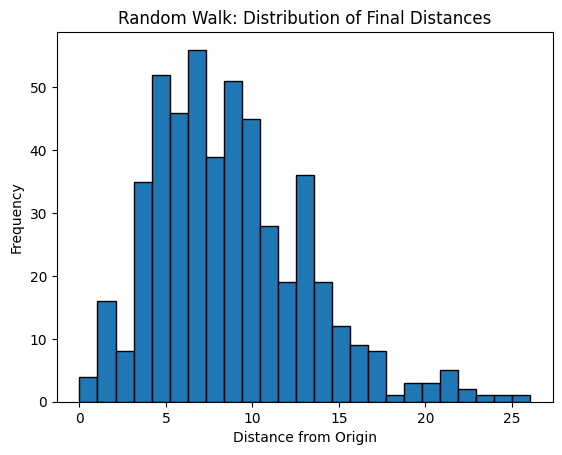

Average r-squared = 96.42 (theoretical value = 100)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Number of random walks and steps
num_walks = 500
num_steps = 100

# Initialize array to store final distances
final_distances = []

# Simulating 500 random walks
for _ in range(num_walks):
    x, y = 0, 0  # starting at the origin
    for _ in range(num_steps):
        # randomly choose the direction: 0 = right, 1 = left, 2 = up, 3 = down
        direction = np.random.choice([0, 1, 2, 3])
        if direction == 0:
            x += 1  # right
        elif direction == 1:
            x -= 1  # left
        elif direction == 2:
            y += 1  # up
        elif direction == 3:
            y -= 1  # down

    # calculate distance from the origin
    distance = np.sqrt(x**2 + y**2)
    final_distances.append(distance)

# Part (b):
plt.hist(final_distances, bins=25, edgecolor='black')
plt.xlabel('Distance from Origin')
plt.ylabel('Frequency')
plt.title('Random Walk: Distribution of Final Distances')
plt.show()

# Part (c):
r_squared_values = [r**2 for r in final_distances]
avg_r_squared = np.mean(r_squared_values)

# shows mean upto 2 decimal places (.2f)
print(f"Average r-squared = {avg_r_squared:.2f} (theoretical value = 100)")


#Question 2: Buffon’s Needle Problem

Estimated pi = 3.1211 (true value = 3.1416, error = 0.65%)


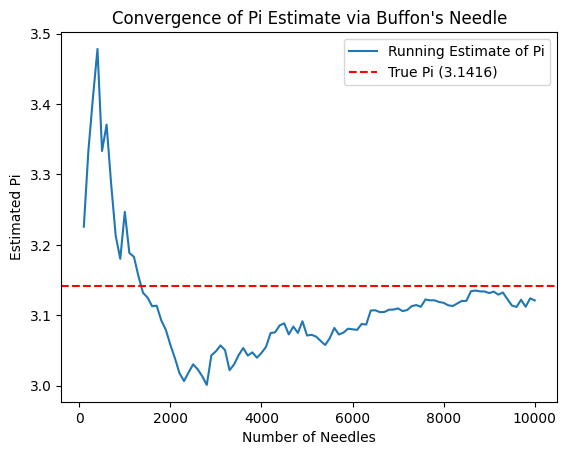

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
L = 0.5  # Length of the needle
true_pi = 3.1416  # True value of pi
total_needles = 10000  # Simulations

# Part (a): Drop 10,000 needles and count the number of crossings
num_crossings = 0

# Create an array to store running estimates
running_estimates = []

for i in range(total_needles):
    # Randomly generate y and θ
    y = np.random.uniform(0, 0.5)  # y is between 0 and 0.5
    theta = np.random.uniform(0, np.pi)  # θ is between 0 and π

    # Check if the needle crosses a line
    if y <= 0.25 * np.sin(theta):
        num_crossings += 1

    # Every 100 needles, estimate pi and store the running estimate
    if (i + 1) % 100 == 0:
        pi_estimate = (2 * (i + 1) * L) / num_crossings
        running_estimates.append(pi_estimate)

# Part (b):
# Estimate pi
pi_estimate = (2 * total_needles * L) / num_crossings
error_percentage = abs((pi_estimate - true_pi) / true_pi) * 100

print(f"Estimated pi = {pi_estimate:.4f} (true value = {true_pi}, error = {error_percentage:.2f}%)")

# Part (c):
plt.plot(range(100, total_needles + 1, 100), running_estimates, label="Running Estimate of Pi")
plt.axhline(y=true_pi, color='r', linestyle='--', label="True Pi (3.1416)")
plt.xlabel("Number of Needles")
plt.ylabel("Estimated Pi")
plt.title("Convergence of Pi Estimate via Buffon's Needle")
plt.legend()
plt.show()


#Question 3: Radioactive Decay


---


A sample initially contains 1000 radioactive nuclei with decay constant λ = 0.01 (inverse
time units). The number of nuclei remaining at time t follows: N(t) = N0 exp(−λt). The
half-life is T1/2 = ln(2)/λ ≈ 69.3 time units.
Simulate individual decay events and compare to the analytical formula.


---


Part (a):

Generate decay times for 1000 nuclei using inverse transform sampling: tdecay =
− ln(U)/λ where U ∼ Uniform(0, 1). Store these times in an array called decay times.


---


Part (b):

At each time point t = 0, 20, 40, 60, . . . , 500, count how many nuclei have not
decayed yet (i.e., tdecay > t). Store these counts in a list called remaining nuclei. Also
compute the analytical curve: N(t) = 1000 exp(−0.01 · t) for the same time points and
store in a list called analytical N.


---


Part (c):

Create a plot with both the simulated data (plot as blue points) and the
analytical curve (plot as a red line). Label the x-axis as “Time (units)” and the y-axis
as “Number of Nuclei”. Add a title “Radioactive Decay: Simulation vs Theory”. Add a
legend. Verify visually that they match closely.

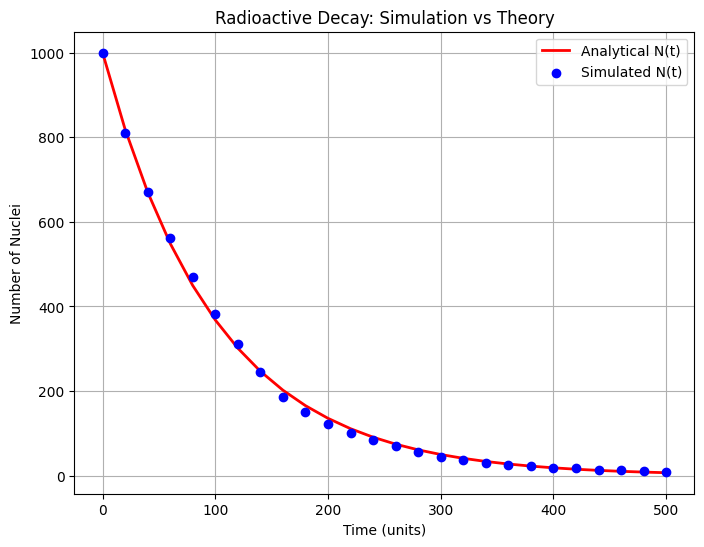

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N0 = 1000  # Initial number of nuclei
lambda_decay = 0.01  # Decay constant (inverse time units)
time_points = np.arange(0, 501, 20)  # Time points (0, 20, 40, ..., 500)

# Part (a): Generate decay times for 1000 nuclei using inverse transform sampling
U = np.random.uniform(0, 1, N0)  # Uniform random variables U
decay_times = -np.log(U) / lambda_decay  # Decay times using inverse transform sampling

# Part (b): Count remaining nuclei at each time point
remaining_nuclei = []
for t in time_points:
    remaining_nuclei.append(np.sum(decay_times > t))  # Count nuclei with decay time > t

# Compute the analytical curve for comparison
analytical_N = N0 * np.exp(-lambda_decay * time_points)

# Part (c): Create the plot
plt.figure(figsize=(8, 6))
plt.plot(time_points, analytical_N, 'r-', label='Analytical N(t)', linewidth=2)
plt.scatter(time_points, remaining_nuclei, color='b', label='Simulated N(t)', zorder=5)
plt.xlabel("Time (units)")
plt.ylabel("Number of Nuclei")
plt.title("Radioactive Decay: Simulation vs Theory")
plt.legend()
plt.grid(True)
plt.show()


#Question 4: High-Dimensional Integration and Curse of Dimensionality

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Part (a)
# Settings
dims = [1, 2, 3, 5, 10]
budget = 100_000
exact_factor = 1 - np.exp(-1)

# Storage
grid_m = []
grid_evals = []
grid_estimates = []
grid_errors = []

mc_estimates = []
mc_errors = []

for d in dims:
    exact_value = exact_factor ** d

    # Grid (midpoint rule)
    m = int(np.floor(budget ** (1 / d)))
    grid_m.append(m)

    evals = m ** d
    grid_evals.append(evals)

    # Midpoints
    axes = [(np.arange(m) + 0.5) / m for _ in range(d)]
    mesh = np.meshgrid(*axes, indexing='ij')
    points = np.stack(mesh, axis=-1).reshape(-1, d)

    values = np.exp(-np.sum(points, axis=1))
    grid_estimate = np.mean(values)

    grid_estimates.append(grid_estimate)
    grid_errors.append(abs(grid_estimate - exact_value))

    # Monte Carlo implementationn
    samples = np.random.rand(budget, d)
    mc_values = np.exp(-np.sum(samples, axis=1))
    mc_estimate = np.mean(mc_values)

    mc_estimates.append(mc_estimate)
    mc_errors.append(abs(mc_estimate - exact_value))


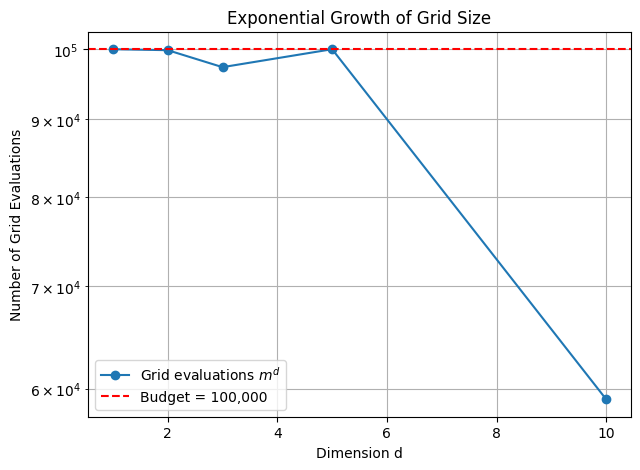

In [ ]:
#Part (b)
plt.figure(figsize=(7,5))
plt.yscale("log")
plt.plot(dims, grid_evals, marker='o', label="Grid evaluations $m^d$")
plt.axhline(budget, color='r', linestyle='--', label="Budget = 100,000")
plt.xlabel("Dimension d")
plt.ylabel("Number of Grid Evaluations")
plt.title("Exponential Growth of Grid Size")
plt.legend()
plt.grid(True, which="both")
plt.show()


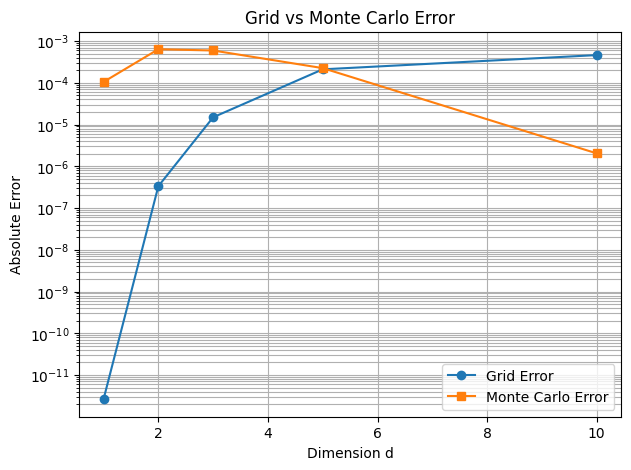

In [ ]:
#Part (b)
plt.figure(figsize=(7,5))
plt.yscale("log")
plt.plot(dims, grid_errors, marker='o', label="Grid Error")
plt.plot(dims, mc_errors, marker='s', label="Monte Carlo Error")
plt.xlabel("Dimension d")
plt.ylabel("Absolute Error")
plt.title("Grid vs Monte Carlo Error")
plt.legend()
plt.grid(True, which="both")
plt.show()


# Part (c)
The grid-based method fails in high dimensions because the number of grid points grows exponentially with dimension, which makes it impossible to maintain sufficient resolution under a fixed computational budget. As dimension increases, the grid becomes extremely coarse, leading to rapidly growing integration error. Monte Carlo integration succeeds because its convergence rate depneds primarily on the number of samples, not on the dimensionality of the space. This makes Monte Carlo methods robust and scalable even in very high dimensions. This means that deterministic grid methods are unsuitable for high-dimensional problems, while Monte Carlo techniques are often the only feasible approach in areas such as statistical physics, Bayesian inference, and ML.